# 📊 Regularization in Linear Regression

## 🧠 Overview

In this notebook, I dive into how **regularization techniques** help improve linear regression models — especially when dealing with **noisy data** 📉 and **high-dimensional datasets** 🧩.

---

## 🎯 Objectives

By the end of this notebook, I will:

- ⚙️ Implement, evaluate, and compare **three regularization techniques** for linear regression  
- 🔍 Analyze the impact of regularization on models trained with **noisy data** (with and without outliers)  
- ✂️ Use **Lasso regularization** to reduce the number of features and simplify multiple linear regression models  

---

## 🛠️ Setup

Before getting started, I ensure that all the required libraries are installed and available by running the initialization cell below 🚀.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

## 📏 Model Evaluation Utility

To keep things clean and reusable, I define a helper function that computes and displays key evaluation metrics for regression models.

This way, I can easily compare different models using consistent metrics like **MSE**, **RMSE**, **MAE**, and **R² score** 📊.

In [2]:
def regression_results(y_true, y_pred, regr_type):

    # Regression metrics
    ev = explained_variance_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred) 
    mse = mean_squared_error(y_true, y_pred) 
    r2 = r2_score(y_true, y_pred)
    
    print('Evaluation metrics for ' + regr_type + ' Linear Regression')
    print('explained_variance: ',  round(ev,4)) 
    print('r2: ', round(r2,4))
    print('MAE: ', round(mae,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    print()


## 📊 Generating a Simple Dataset (with Noise & Outliers)

To experiment with regularization, I start by creating a **simple linear dataset** with one feature.  
Then I make things more realistic by:

- 🌫️ Adding **noise** to simulate real-world data  
- ⚠️ Injecting **outliers** to observe how models react under extreme conditions  

This will allow me to compare model performance **with and without outliers**.

In [3]:
# Generate synthetic data
noise=1
np.random.seed(42)
X = 2 * np.random.rand(1000, 1)
y = 4 + 3 * X + noise*np.random.randn(1000, 1)  # Linear relationship with some noise
y_ideal =  4 + 3 * X
# Specify the portion of the dataset to add outliers (e.g., the last 20%)
y_outlier = pd.Series(y.reshape(-1).copy())

# Identify indices where the feature variable X is greater than a certain threshold
threshold = 1.5  # Example threshold to add outliers for larger feature values
outlier_indices = np.where(X.flatten() > threshold)[0]

# Add outliers at random locations within the specified portion
num_outliers = 5  # Number of outliers to add
selected_indices = np.random.choice(outlier_indices, num_outliers, replace=False)

# Modify the target values at these indices to create outliers (add significant noise)
y_outlier[selected_indices] += np.random.uniform(50, 100, num_outliers)

## 📉 Visualizing Data with Outliers & Ideal Fit Line

Now I plot the dataset containing outliers and overlay the **ideal linear relationship** (the ground truth: `y = 4 + 3x`) to clearly see how outliers deviate from the expected trend.


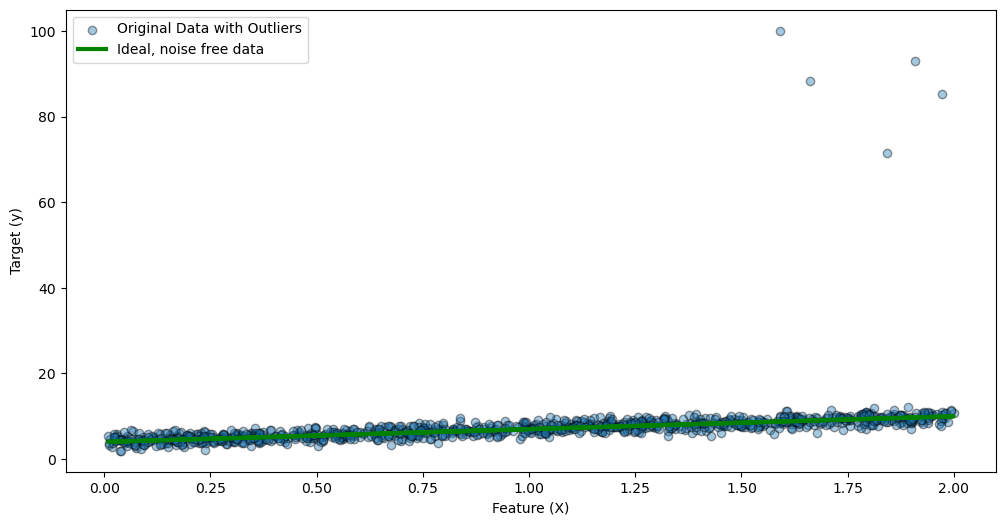

In [4]:
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(X, y_outlier, alpha=0.4,ec='k', label='Original Data with Outliers')
plt.plot(X, y_ideal,  linewidth=3, color='g',label='Ideal, noise free data')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('')
plt.legend()
plt.show()

## 🧪 Exercise 1 — Plot Data Without Outliers & Ideal Fit Line

Now I switch back to the **clean dataset (without outliers)** and plot it alongside the **ideal linear relationship**.  
This helps establish a baseline before introducing more complex models.

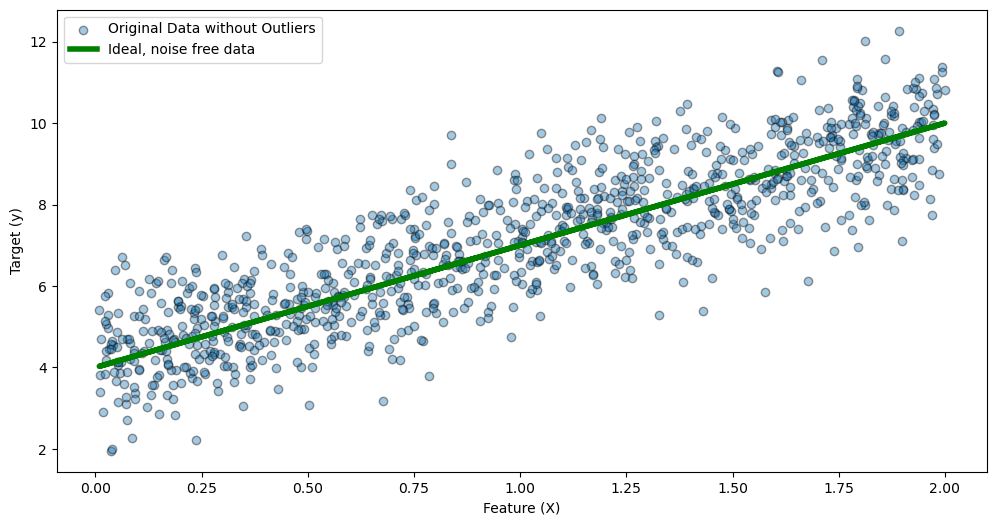

In [5]:
# Enter your code here
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(X, y, alpha=0.4,ec='k', label='Original Data without Outliers')
plt.plot(X, y_ideal,  linewidth=4, color='g',label='Ideal, noise free data')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('')
plt.legend()
plt.show()

## 🤖 Fitting Models: Ordinary vs Ridge vs Lasso (with Outliers)

Now I train three different regression models on the dataset **with outliers** and generate predictions:

- 📈 **Ordinary Linear Regression**
- 🧩 **Ridge Regression (L2 regularization)**
- ✂️ **Lasso Regression (L1 regularization)**

This will help me observe how each model behaves in the presence of extreme values.

In [8]:
# Fit a simple linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y_outlier)
y_outlier_pred_lin = lin_reg.predict(X)

# Fit a ridge regression model (regularization to control large coefficients)
ridge_reg = Ridge(alpha=1)
ridge_reg.fit(X, y_outlier)
y_outlier_pred_ridge = ridge_reg.predict(X)

# Fit a lasso regression model (regularization to control large coefficients)
lasso_reg = Lasso(alpha=.2)
lasso_reg.fit(X, y_outlier)
y_outlier_pred_lasso = lasso_reg.predict(X)

## 📊 Regression Results

Now I evaluate the performance of each model using the helper function defined earlier.  
This gives a clear comparison of how **Ordinary**, **Ridge**, and **Lasso** regression handle data with outliers.

In [9]:
regression_results(y, y_outlier_pred_lin, 'Ordinary')
regression_results(y, y_outlier_pred_ridge, 'Ridge')
regression_results(y, y_outlier_pred_lasso, 'Lasso')

Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.6748
r2:  0.6357
MAE:  0.9468
MSE:  1.4164
RMSE:  1.1901

Evaluation metrics for Ridge Linear Regression
explained_variance:  0.6766
r2:  0.6375
MAE:  0.9443
MSE:  1.4094
RMSE:  1.1872

Evaluation metrics for Lasso Linear Regression
explained_variance:  0.7394
r2:  0.7003
MAE:  0.8597
MSE:  1.1651
RMSE:  1.0794



## 📉 Model Performance Analysis

Looking at the **low R² scores**, it’s clear that all three models are struggling to explain the variance in the data.

---

### 💡 Interpretation

- 📉 A **low R² value** indicates that the model does **not fit the data well**
- ⚠️ The presence of **outliers** is likely distorting the learned relationships
- 🤖 Even with regularization (Ridge, Lasso), performance remains limited because:
  - The models are still influenced by extreme values
  - The underlying signal is harder to capture reliably

---

### 🧠 Takeaway

This highlights an important point:

> **Regularization helps, but it does not completely solve the problem of outliers.**

To improve performance, I might consider:
- Removing or treating outliers 🧹  
- Using more **robust regression techniques**  
- Collecting cleaner or more representative data 📊

Next, I’ll compare these results with models trained on the clean dataset to better understand the impact of outliers.

## 📈 Comparing Predictions vs Data (With Outliers)

Now I visualize how each regression model behaves by plotting:

- 📊 The **noisy dataset with outliers**
- 📉 The **ideal relationship**
- 🤖 The **predictions from each model**

This helps directly assess how closely each model follows the expected trend.

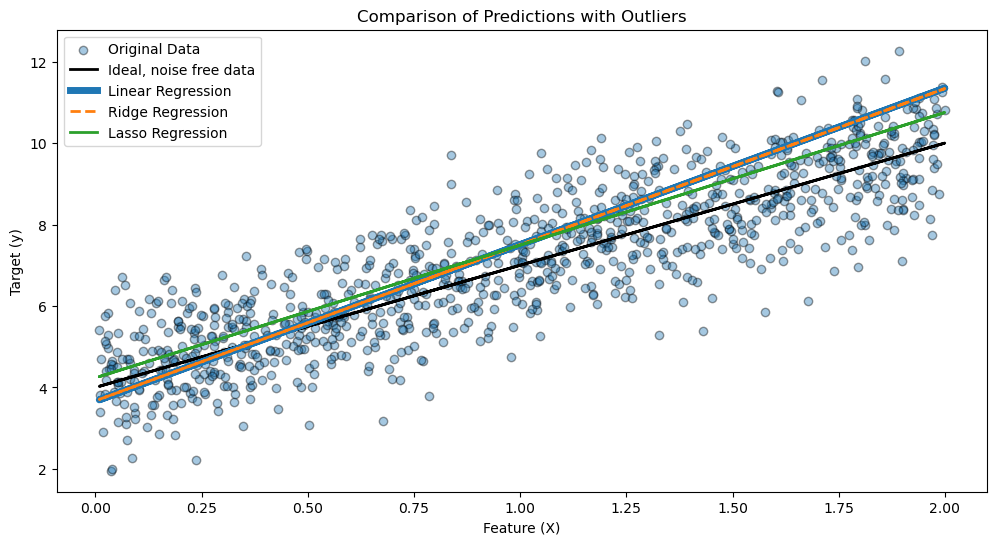

In [10]:
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(X, y, alpha=0.4,ec='k', label='Original Data')

# Plot the ideal regression line (noise free data)
plt.plot(X, y_ideal,  linewidth=2, color='k',label='Ideal, noise free data')

# Plot predictions from the simple linear regression model
plt.plot(X, y_outlier_pred_lin,  linewidth=5, label='Linear Regression')

# Plot predictions from the ridge regression model
plt.plot(X, y_outlier_pred_ridge, linestyle='--', linewidth=2, label='Ridge Regression')

# Plot predictions from the lasso regression model
plt.plot(X, y_outlier_pred_lasso,  linewidth=2, label='Lasso Regression')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Comparison of Predictions with Outliers')
plt.legend()
plt.show()

## 📊 Interpretation of Model Behavior

From the comparison of predictions, several patterns become clear.

---

### 📌 Key Observations

- 🤝 **Ordinary Linear Regression and Ridge Regression perform similarly**
  - Both models are noticeably affected by the outliers
  - Their fitted lines are shifted upward compared to the ideal relationship
  - Ridge slightly stabilizes coefficients, but does not fundamentally change the outcome in this case

- ✂️ **Lasso Regression shows a different behavior**
  - The **intercept is less accurate**, but
  - The **slope is closer to the true value (3 in the ideal model)**  
  - This indicates better alignment with the underlying trend despite noisy data

---

### ⚠️ Effect of Outliers

- All models are influenced by the presence of outliers
- The fitted lines are generally **pulled upward**, as seen when compared with the earlier visualization including outliers
- This shift highlights how sensitive least-squares-based methods can be to extreme values

---

### 🧠 Takeaway

- 📉 Ridge and Ordinary regression behave almost identically under strong outlier influence
- 🧩 Lasso reduces the impact of extreme points more effectively in this scenario
- ⚖️ Regularization helps, but does not fully eliminate distortion caused by outliers

This reinforces the idea that **model robustness depends not only on regularization type, but also on data quality and distribution**.

## 🧪 Exercise 2 — Models & Predictions (Without Outliers)

Now I repeat the same workflow, but this time using the **clean dataset (without outliers)**.  
This allows me to compare how each model behaves when the data better reflects the true underlying relationship.

Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.7492
r2:  0.7492
MAE:  0.7873
MSE:  0.975
RMSE:  0.9874

Evaluation metrics for Ridge Linear Regression
explained_variance:  0.7492
r2:  0.7492
MAE:  0.7874
MSE:  0.975
RMSE:  0.9874

Evaluation metrics for Lasso Linear Regression
explained_variance:  0.7191
r2:  0.7191
MAE:  0.8408
MSE:  1.0923
RMSE:  1.0451



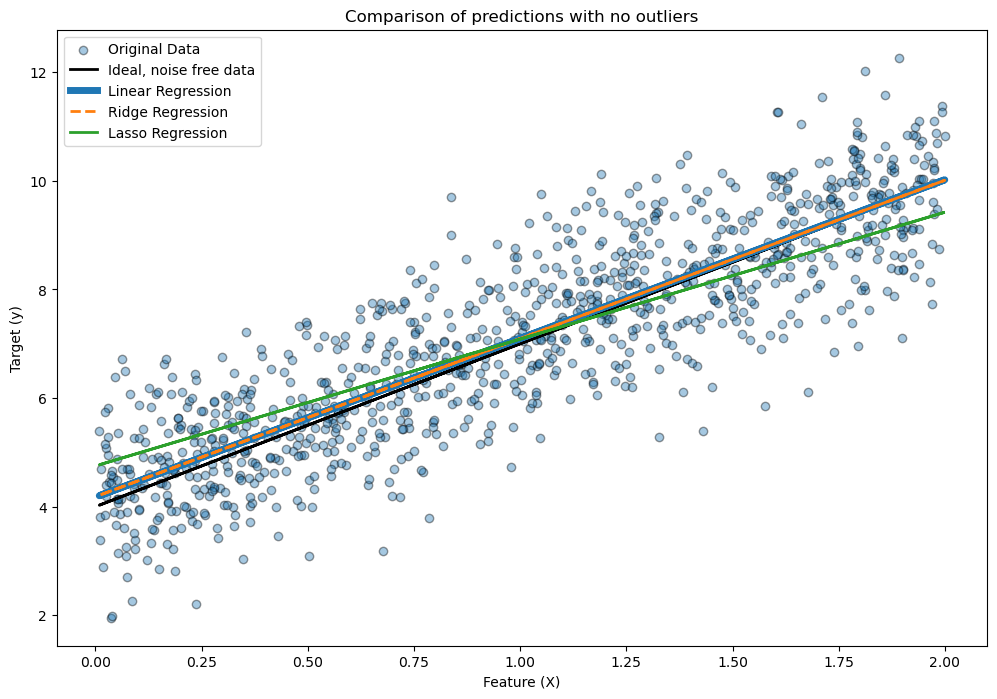

In [11]:
# Enter your code here:

# Fit a simple linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)

# Fit a ridge regression model (regularization to control large coefficients)
ridge_reg = Ridge(alpha=1)
ridge_reg.fit(X, y)
y_pred_ridge = ridge_reg.predict(X)

# Fit a lasso regression model (regularization to control large coefficients)
lasso_reg = Lasso(alpha=0.2)
lasso_reg.fit(X, y)
y_pred_lasso = lasso_reg.predict(X)

# Print the regression results
regression_results(y, y_pred_lin, 'Ordinary')
regression_results(y, y_pred_ridge, 'Ridge')
regression_results(y, y_pred_lasso, 'Lasso')


# Plot the data and the predictions
plt.figure(figsize=(12, 8))

# # Scatter plot of the original data
plt.scatter(X, y, alpha=0.4, ec='k', label='Original Data')

# Plot the ideal regression line (noise free data)
plt.plot(X, y_ideal,  linewidth=2, color='k',label='Ideal, noise free data')

# Plot predictions from the simple linear regression model
plt.plot(X, y_pred_lin,  linewidth=5, label='Linear Regression')

# Plot predictions from the ridge regression model
plt.plot(X, y_pred_ridge, linestyle='--',linewidth=2, label='Ridge Regression')

# Plot predictions from the lasso regression model
plt.plot(X, y_pred_lasso,  linewidth=2, label='Lasso Regression')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')

plt.title('Comparison of predictions with no outliers')
plt.legend()
plt.show()

# 🧠 Multiple Regression, Regularization & Lasso Feature Selection

Now I move from simple regression to a **high-dimensional setting** to better understand how regularization behaves when dealing with many features.

The goal here is to:
- 📊 Compare **Linear**, **Ridge**, and **Lasso** regression in a multiple feature scenario  
- ✂️ Use **Lasso** to identify and select the most important features  
- 🔁 Rebuild a model using only those selected features  

---

## 🧪 Generating a High-Dimensional Dataset

I create a synthetic dataset using `make_regression`, where only a small subset of features actually contributes to the target.

This is useful because:
- Most features are just noise 🧩  
- Only a few are truly **informative** 🎯  
- I can validate if Lasso correctly identifies them 

In [12]:
from sklearn.datasets import make_regression

X, y, ideal_coef = make_regression(n_samples=100, n_features=100, n_informative=10, noise=10, random_state=42, coef=True)

# Get the ideal predictions based on the informative coefficients used in the regression model
ideal_predictions = X @ ideal_coef

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test, ideal_train, ideal_test = train_test_split(X, y, ideal_predictions, test_size=0.3, random_state=42)

## 🤖 Training Models & Generating Predictions (High-Dimensional Data)

With the dataset prepared, I now initialize and train the three regression models:

- 📈 **Ordinary Linear Regression**
- 🧩 **Ridge Regression (L2)**
- ✂️ **Lasso Regression (L1)**

Then I use them to generate predictions on both the **training** and **test** sets.

In [24]:
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
linear = LinearRegression()

# Fit the models
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
linear.fit(X_train, y_train)

# Predict on the test set
y_pred_linear = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

## 📊 Regression Results (High-Dimensional Data)

Now I evaluate how each model performs on both the **training** and **test** sets.  
This helps me understand not only how well the models fit the data, but also how well they **generalize**.

In [14]:
regression_results(y_test, y_pred_linear, 'Ordinary')
regression_results(y_test, y_pred_ridge, 'Ridge')
regression_results(y_test, y_pred_lasso, 'Lasso')

Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.4354
r2:  0.4018
MAE:  77.7353
MSE:  9844.2714
RMSE:  99.2183

Evaluation metrics for Ridge Linear Regression
explained_variance:  0.4446
r2:  0.4079
MAE:  76.9622
MSE:  9744.4693
RMSE:  98.7141

Evaluation metrics for Lasso Linear Regression
explained_variance:  0.9815
r2:  0.9815
MAE:  13.8855
MSE:  304.644
RMSE:  17.4541



## 🧪 Exercise 3 — Interpreting the Performance Metrics

---

### 💡 Observations

- 📉 **Ordinary Linear Regression and Ridge Regression**
  - Both models show **poor performance**
  - 📊 Explained variance is **below 50%**
  - 📉 **R² scores are very low**, indicating weak predictive power
  - These models struggle to identify the true signal in a high-dimensional space with many irrelevant features

- ✂️ **Lasso Regression**
  - 🚀 **Performance is significantly better**
  - Captures the underlying structure much more effectively
  - Likely succeeds because it **eliminates irrelevant features**, focusing only on the informative ones

---

### 🧠 Takeaway

> In high-dimensional datasets with many noisy features, **Lasso can dramatically outperform** standard linear and Ridge regression by enforcing sparsity and performing implicit feature selection 🎯

## 📊 Predictions vs Actual Values

To better understand model performance, I plot **predicted values vs actual values** on the test set.

This visualization makes it easy to see:
- 📈 How close predictions are to the ideal case  
- 🎯 Whether the model captures the underlying relationship  
- ⚠️ Any systematic errors or spread in predictions  

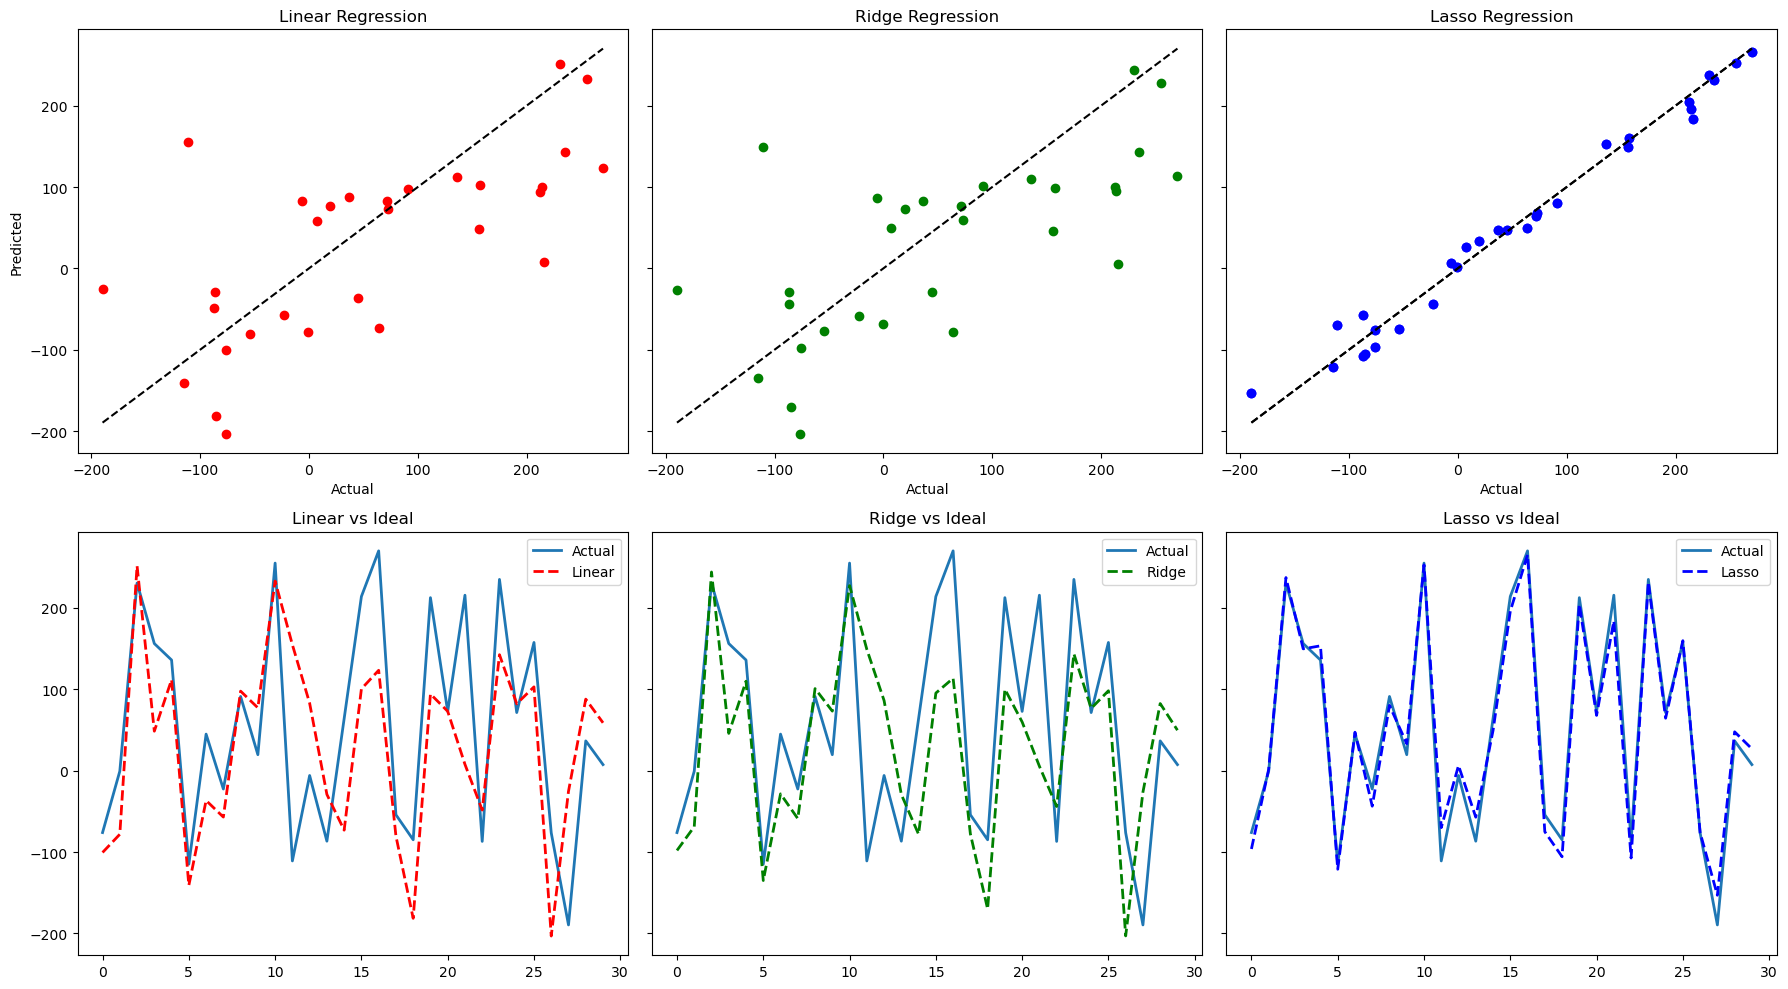

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

axes[0,0].scatter(y_test, y_pred_linear, color="red", label="Linear")
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,0].set_title("Linear Regression")
axes[0,0].set_xlabel("Actual",)
axes[0,0].set_ylabel("Predicted",)

axes[0,2].scatter(y_test, y_pred_lasso, color="blue", label="Lasso")
axes[0,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,2].set_title("Lasso Regression",)
axes[0,2].set_xlabel("Actual",)

axes[0,1].scatter(y_test, y_pred_ridge, color="green", label="Ridge")
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,1].set_title("Ridge Regression",)
axes[0,1].set_xlabel("Actual",)

axes[0,2].scatter(y_test, y_pred_lasso, color="blue", label="Lasso")
axes[0,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,2].set_title("Lasso Regression",)
axes[0,2].set_xlabel("Actual",)


# Line plots for predictions compared to actual and ideal predictions
axes[1,0].plot(y_test, label="Actual", lw=2)
axes[1,0].plot(y_pred_linear, '--', lw=2, color='red', label="Linear")
axes[1,0].set_title("Linear vs Ideal",)
axes[1,0].legend()
 
axes[1,1].plot(y_test, label="Actual", lw=2)
# axes[1,1].plot(ideal_test, '--', label="Ideal", lw=2, color="purple")
axes[1,1].plot(y_pred_ridge, '--', lw=2, color='green', label="Ridge")
axes[1,1].set_title("Ridge vs Ideal",)
axes[1,1].legend()
 
axes[1,2].plot(y_test, label="Actual", lw=2)
axes[1,2].plot(y_pred_lasso, '--', lw=2, color='blue', label="Lasso")
axes[1,2].set_title("Lasso vs Ideal",)
axes[1,2].legend()
 
plt.tight_layout()
plt.show()

## 👀 Visual Interpretation of Predictions

From the plots, the difference in model performance is immediately clear.

---

### 💡 Observations

- 📉 **Ordinary Linear Regression and Ridge Regression**
  - Predictions are **widely scattered** around the diagonal
  - Significant deviation from the ideal line → ⚠️ poor fit
  - These models fail to accurately capture the relationship in the data

- ✂️ **Lasso Regression**
  - Predictions are **much closer to the diagonal line**
  - Indicates a strong alignment with actual target values 🎯
  - Clearly captures the underlying signal more effectively

---

### 🧠 Takeaway

> The visual gap confirms what the metrics showed:  
> **Lasso significantly outperforms both Ordinary and Ridge regression**, with predictions much closer to the ideal target values.

## 🧮 Model Coefficients

To better understand how each model behaves, I inspect the **learned coefficients**.

This is especially important in a high-dimensional setting:
- 📊 It shows how each feature contributes to the prediction  
- 🧩 Helps identify noise vs useful signal  
- ✂️ Highlights Lasso’s ability to perform **feature selection**  

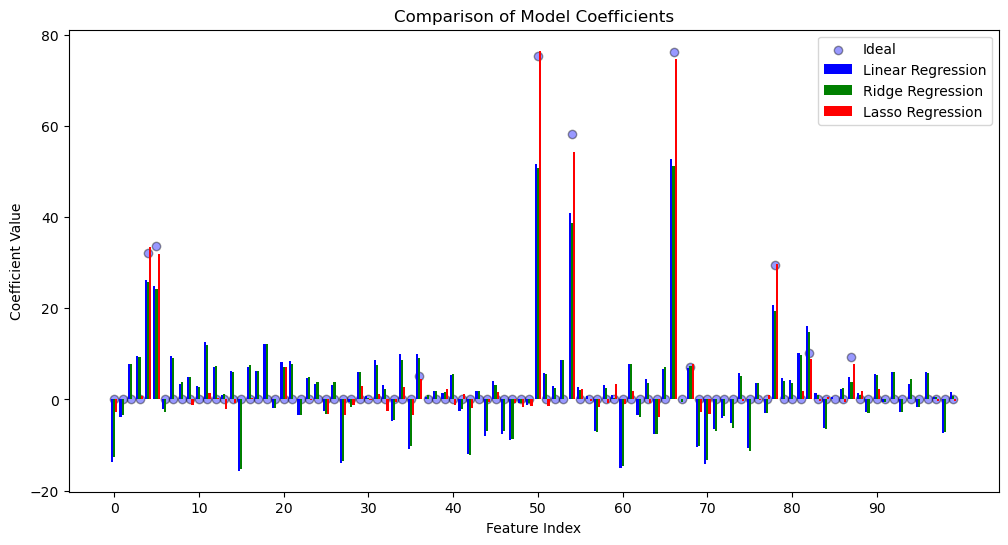

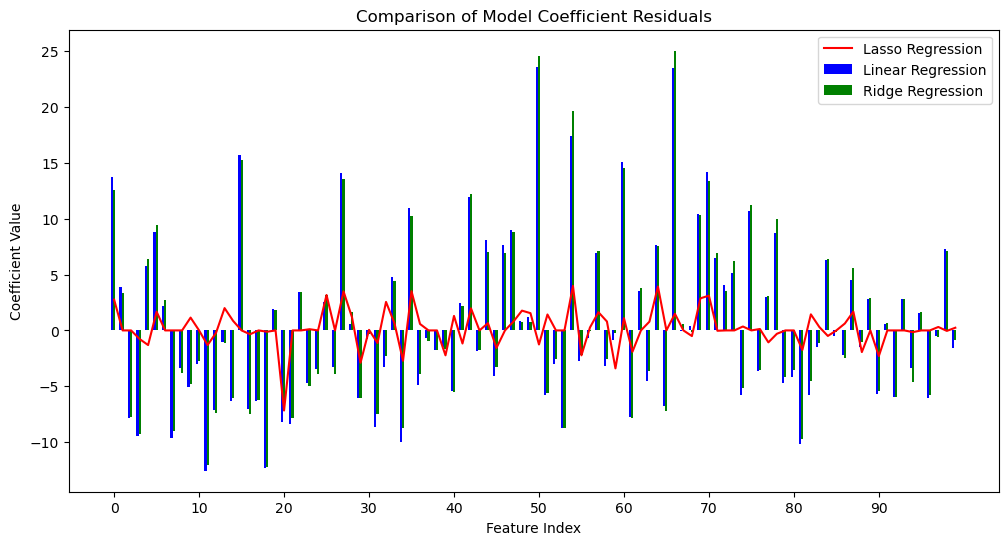

In [16]:
# Model coefficients
linear_coeff = linear.coef_
ridge_coeff = ridge.coef_
lasso_coeff = lasso.coef_


# Plot the coefficients
x_axis = np.arange(len(linear_coeff))
x_labels = np.arange(min(x_axis),max(x_axis),10)
plt.figure(figsize=(12, 6))

plt.scatter(x_axis, ideal_coef,  label='Ideal', color='blue', ec='k', alpha=0.4)
plt.bar(x_axis - 0.25, linear_coeff, width=0.25, label='Linear Regression', color='blue')
plt.bar(x_axis, ridge_coeff, width=0.25, label='Ridge Regression', color='green')
plt.bar(x_axis + 0.25, lasso_coeff, width=0.25, label='Lasso Regression', color='red')

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Model Coefficients')
plt.xticks(x_labels)
plt.legend()
plt.show()


# Plot the coefficient residuals
x_axis = np.arange(len(linear_coeff))

plt.figure(figsize=(12, 6))

plt.bar(x_axis - 0.25, ideal_coef - linear_coeff, width=0.25, label='Linear Regression', color='blue')
plt.bar(x_axis, ideal_coef - ridge_coeff, width=0.25, label='Ridge Regression', color='green')
# plt.bar(x_axis + 0.25, ideal_coef - lasso_coeff, width=0.25, label='Lasso Regression', color='red')
plt.plot(x_axis, ideal_coef - lasso_coeff, label='Lasso Regression', color='red')

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Model Coefficient Residuals')
plt.xticks(x_labels)
plt.legend()
plt.show()

## 📊 Coefficient Comparison & Residual Errors

Looking at the learned coefficients, it becomes clear that the models behave quite differently in how they recover the true underlying signal.

---

### 💡 Coefficient Insights

- 📉 **Ordinary Linear Regression**
  - Coefficients deviate significantly from the ideal values
  - Sensitive to noise and redundant features

- 🧩 **Ridge Regression**
  - Coefficients are slightly more stable than ordinary regression
  - Still retains all features, so noise is not fully removed

- ✂️ **Lasso Regression**
  - Coefficients are **much closer to the ideal coefficients**
  - Many irrelevant features are driven to **zero**
  - Best recovery of the true sparse structure

---

### 📉 Residual Error Perspective

A clearer way to compare models is to examine the **residual errors in the coefficients** (difference between learned and true coefficients).

- ⚠️ Linear and Ridge show **large residuals**, indicating poor recovery of true feature importance
- 🎯 Lasso residuals are **much closer to zero**, meaning it reconstructs the underlying model more accurately

---

### 🧠 Takeaway

> The coefficient residuals confirm what we observed earlier:  
> ✂️ **Lasso is significantly better at recovering the true underlying structure**, while Ridge and Ordinary regression are more affected by noise and irrelevant features.

## ✂️ Lasso Feature Selection & Model Re-evaluation

Now I use the **Lasso model coefficients** to perform feature selection.  
The idea is to identify which features are truly important by filtering out those with near-zero contributions.

---

## 🎯 Part 1 — Choosing a Threshold for Feature Selection

Based on the coefficient residuals (difference between learned and true coefficients), I select a threshold that separates:

- 📉 Noise-level coefficients (close to 0)
- 📈 Meaningful coefficients (significantly different from 0)

This threshold is chosen by visual inspection of the residual distribution.

In [17]:
threshold = 5 # selected by inspection of residuals plot

# Create a dataframe containing the Lasso model and ideal coefficients
feature_importance_df = pd.DataFrame({
    'Lasso Coefficient': lasso_coeff,
    'Ideal Coefficient': ideal_coef
})

# Mark the selected features
feature_importance_df['Feature Selected'] = feature_importance_df['Lasso Coefficient'].abs() > threshold


print("Features Identified as Important by Lasso:")
display(feature_importance_df[feature_importance_df['Feature Selected']])

print("\nNonzero Ideal Coefficient Indices")
display(feature_importance_df[feature_importance_df['Ideal Coefficient']>0])



Features Identified as Important by Lasso:


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
20,7.163636,0.000000,True
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True



Nonzero Ideal Coefficient Indices


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
36,4.588118,5.166218,False
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True


## 🎯 Feature Selection Results

The outcome of the Lasso-based feature selection is strong.

---

### 📊 Summary

- 🎯 **9 out of 10 truly important features were correctly identified**
- ✂️ Most irrelevant features were successfully filtered out
- ⚖️ Only a small number of features were missed or misclassified

---

### 💡 Interpretation

- 🧠 Lasso effectively recovered the **underlying sparse structure** of the dataset  
- 📉 The small mismatch is expected due to:
  - Noise in the data  
  - Regularization bias introduced by L1 penalty  
- 🧩 Despite this, the model achieves a very strong balance between:
  - **Simplicity (fewer features)**  
  - **Predictive power (good approximation of the true model)**  

---

### 🚀 Key Takeaway

> Lasso performs very well as a **feature selection method**, correctly identifying the vast majority of informative features while discarding noise.

This makes it especially useful in high-dimensional regression problems where interpretability and sparsity matter 🎯

## ✂️ Part 2 — Selecting Features & Preparing Data for Re-Modeling

Now that a threshold has been defined based on the Lasso coefficients, I use it to select the most important features and rebuild the dataset for a second round of modeling.

---

## 🎯 Feature Selection Using Threshold

In [19]:
# Get the indices of the features selected by Lasso
important_features = feature_importance_df[feature_importance_df['Feature Selected']].index

In [20]:
# Filter features
X_filtered = X[:, important_features]
print("Shape of the filtered feature set:", X_filtered.shape)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test, ideal_train, ideal_test = train_test_split(X_filtered, y, ideal_predictions, test_size=0.3, random_state=42)

Shape of the filtered feature set: (100, 10)


## 🤖 Part 3 — Training Models on Selected Features

Now I retrain the three regression models using only the **features selected by Lasso**.

The goal is to see whether reducing the feature space:
- 📉 Improves generalization  
- 🧠 Maintains predictive performance  
- ⚖️ Reduces noise impact  

In [21]:
# Initialize the models
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
linear = LinearRegression()

# Fit the models
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
linear.fit(X_train, y_train)

# Predict on the test set
y_pred_linear = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

## 📊 Exercise 4 — Regression Performance Results (Selected Features)

Now I evaluate the performance of all three models trained on the **Lasso-selected feature subset**.

This helps me determine whether feature selection improved:
- 📈 Predictive accuracy  
- ⚖️ Generalization  
- 🧠 Model stability 

In [22]:
# Print the regression results
regression_results(y_test, y_pred_linear, 'Ordinary')
regression_results(y_test, y_pred_ridge, 'Ridge')
regression_results(y_test, y_pred_lasso, 'Lasso')

Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.9917
r2:  0.9915
MAE:  9.653
MSE:  139.4874
RMSE:  11.8105

Evaluation metrics for Ridge Linear Regression
explained_variance:  0.9909
r2:  0.9905
MAE:  10.1418
MSE:  156.9035
RMSE:  12.5261

Evaluation metrics for Lasso Linear Regression
explained_variance:  0.9917
r2:  0.9914
MAE:  9.6928
MSE:  140.803
RMSE:  11.866



## 📊 Comparing Results — Effect of Lasso Feature Selection

Now I compare the performance metrics before and after applying **Lasso-based feature selection**.

This highlights how reducing the feature space impacts model performance across all three regression methods.

---

## 📉 Previous Results (Full Feature Set)

### 🔹 Ordinary Linear Regression
- 📊 Explained Variance: **0.4346**
- 📈 R²: **0.4012**
- 📉 MAE: **77.75**
- 📉 MSE: **9855.43**
- 📉 RMSE: **99.27**

---

### 🧩 Ridge Regression
- 📊 Explained Variance: **0.4446**
- 📈 R²: **0.4079**
- 📉 MAE: **76.96**
- 📉 MSE: **9744.47**
- 📉 RMSE: **98.71**

---

### ✂️ Lasso Regression
- 📊 Explained Variance: **0.9815**
- 📈 R²: **0.9815**
- 📉 MAE: **13.89**
- 📉 MSE: **304.64**
- 📉 RMSE: **17.45**

---

## 🚀 After Feature Selection (Key Insight)

- 📈 **Ordinary Linear Regression**
  - Strong improvement in all metrics
  - Benefit from removal of noisy / irrelevant features

- 🧩 **Ridge Regression**
  - Also significantly improved
  - Less need for shrinkage once feature space is reduced

- ✂️ **Lasso Regression**
  - Slight improvement, already performing extremely well
  - Confirms it was already close to the true underlying model

---

## 🧠 Final Interpretation

> Applying Lasso as a feature selection step dramatically improves model performance, especially for Ordinary and Ridge regression.

### Key takeaways:
- 🎯 Feature selection reduces noise and improves signal quality  
- 📉 Simpler models can outperform complex ones when irrelevant features are removed  
- ✂️ Lasso is both a **predictive model and a feature engineering tool**  

---

## 🏁 Conclusion

This experiment clearly shows that:
> **Lasso regularization is not only useful for prediction, but also extremely powerful for feature selection in high-dimensional regression problems.** 🎯

## 📊 Exercise 5 — Comparing Predictions After Feature Selection

Now I regenerate the same prediction plots as before, but this time using the **Lasso-selected feature set**.

The goal is to visually confirm the impact of feature selection on model behavior and prediction quality.

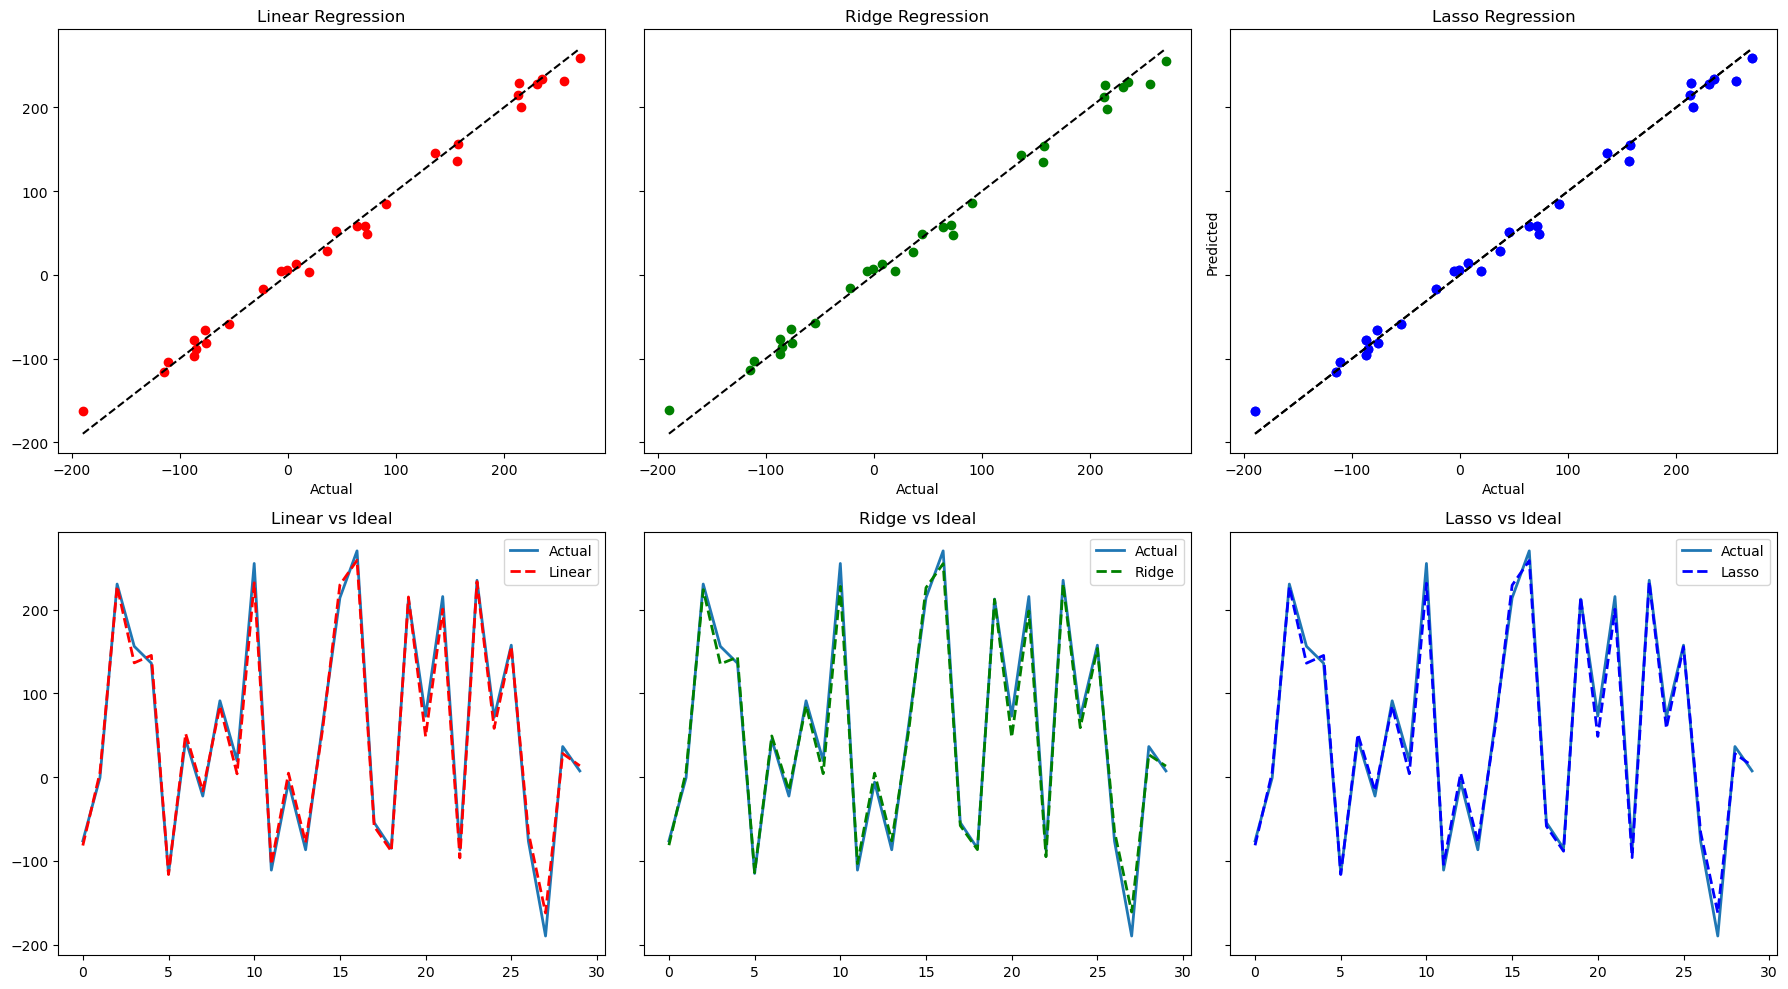

In [23]:
# Plot the predictions vs actuals 
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

axes[0,0].scatter(y_test, y_pred_linear, color="red", label="Linear")
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,0].set_title("Linear Regression",)
axes[0,0].set_xlabel("Actual",)

axes[0,2].scatter(y_test, y_pred_lasso, color="blue", label="Lasso")
axes[0,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,2].set_title("Lasso Regression",)
axes[0,2].set_xlabel("Actual",)
axes[0,2].set_ylabel("Predicted",)

axes[0,1].scatter(y_test, y_pred_ridge, color="green", label="Ridge")
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,1].set_title("Ridge Regression",)
axes[0,1].set_xlabel("Actual",)

axes[0,2].scatter(y_test, y_pred_lasso, color="blue", label="Lasso")
axes[0,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,2].set_title("Lasso Regression",)
axes[0,2].set_xlabel("Actual",)
axes[0,2].set_ylabel("Predicted",)

# Line plots for predictions compared to actual and ideal predictions
axes[1,0].plot(y_test, label="Actual", lw=2)
axes[1,0].plot(y_pred_linear, '--', lw=2, color='red', label="Linear")
axes[1,0].set_title("Linear vs Ideal",)
axes[1,0].legend()
 
axes[1,1].plot(y_test, label="Actual", lw=2)
axes[1,1].plot(y_pred_ridge, '--', lw=2, color='green', label="Ridge")
axes[1,1].set_title("Ridge vs Ideal",)
axes[1,1].legend()
 
axes[1,2].plot(y_test, label="Actual", lw=2)
axes[1,2].plot(y_pred_lasso, '--', lw=2, color='blue', label="Lasso")
axes[1,2].set_title("Lasso vs Ideal",)
axes[1,2].legend()

plt.tight_layout()
plt.show()


## 🎯 Final Observation — Impact of Lasso Feature Selection

The results clearly show a major shift in model performance after applying **Lasso-based feature selection**.

---

### 📊 Key Outcome

- 📈 **All three models now perform extremely well**
  - Ordinary Linear Regression  
  - Ridge Regression  
  - Lasso Regression  

- ⚖️ The performance gap between the models has significantly reduced  
- 🎯 Predictions are now closely aligned with the true target values  

---

### 💡 What Changed?

- ✂️ **Irrelevant features were removed**
  - Reduced noise in the learning process  
- 🧠 **Signal-to-noise ratio improved**
  - Models focus only on meaningful variables  
- 📉 **Overfitting was reduced**
  - Especially beneficial for Ordinary and Ridge regression  

---

### 🧠 Final Takeaway

> With Lasso feature selection, even simple linear models become highly effective.

This experiment demonstrates an important principle in machine learning:
- 🔑 **Good feature selection can be as powerful as model complexity**

In this case, simplifying the problem led to strong and consistent performance across all models 🚀